# TD 03 - Clustering NLP (ML)

## Objectif du TD
Construire un pipeline non supervise pour regrouper des textes medicaux proches.

Probleme a resoudre: trouver des groupes coherents sans labels.

Pipeline vise:
1) texte -> pretraitement,
2) TF-IDF,
3) clustering (K-Means et Hierarchical),
4) evaluation intrinsique (silhouette) + visualisation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

## Etape 1 - Chargement du dataset

Dataset impose (clustering): `mteb/medrxiv-clustering-p2p`.

A faire:
- charger le dataset,
- construire une liste `texts` (une chaine par document),
- prendre un sous-ensemble pour accelerer le TD.

In [ ]:
from datasets import load_dataset

ds = load_dataset("mteb/medrxiv-clustering-p2p")
TEXT_COL = "sentences"

# On limite la taille pour garder un TD rapide a executer
N = min(10000, len(ds["test"]))
texts_raw = list(ds["test"][TEXT_COL][:N])

print("Nombre d'exemples utilises:", N)

Nombre d'exemples utilises: 10000


## Etape 2 - Pretraitement + TF-IDF

A faire:
- pretraitement simple,
- TF-IDF,
- afficher la shape de la matrice vectorisee.
- eventuellement: SVD pour reduire la dimensionnalite.

In [ ]:
import re
import unicodedata

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD

# 2) Pretraitement simple
def preprocess_text(text):
    text = text.lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8", "ignore")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = [tok for tok in text.split() if tok not in ENGLISH_STOP_WORDS]
    return " ".join(tokens)

texts = [preprocess_text(t) for t in texts_raw]

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
X = tfidf.fit_transform(texts)
print("Shape TF-IDF:", X.shape)

# On reduit un peu la dimension pour simplifier clustering + visualisation
svd_100 = TruncatedSVD(n_components=100, random_state=42)
X_100 = svd_100.fit_transform(X)

Shape TF-IDF: (10000, 20000)


## Etape 3 - K-Means et choix de K

A faire:
- tester plusieurs valeurs de K,
- comparer avec silhouette score,
- retenir un K raisonnable.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 3) K-Means: comparaison de plusieurs K
candidate_k = [4, 6, 8, 10]
rows = []

for k in candidate_k:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels_km = km.fit_predict(X_100)
    sil = silhouette_score(X_100, labels_km)
    rows.append({"K": k, "Silhouette": sil, "Inertia": km.inertia_})

k_df = pd.DataFrame(rows).sort_values("Silhouette", ascending=False)
display(k_df)

best_k = int(k_df.iloc[0]["K"])
print("K retenu (silhouette max):", best_k)

km_best = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
labels_km_best = km_best.fit_predict(X_100)


,K,Silhouette,Inertia
3,10,0.066846,1294.185613
0,4,0.066180,1410.875834
2,8,0.059840,1339.564147
1,6,0.051678,1385.746759


K retenu (silhouette max): 10


## Etape 4 - Clustering hierarchique

A faire:
- appliquer `AgglomerativeClustering` avec le meme K,
- comparer rapidement au K-Means.

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# 4) Clustering hierarchique avec le meme K
agg = AgglomerativeClustering(n_clusters=best_k)
labels_agg = agg.fit_predict(X_100)
sil_agg = silhouette_score(X_100, labels_agg)
sil_km = silhouette_score(X_100, labels_km_best)

print(f"Silhouette KMeans (K={best_k}): {sil_km:.4f}")
print(f"Silhouette Agglomerative (K={best_k}): {sil_agg:.4f}")


Silhouette KMeans (K=10): 0.0668
Silhouette Agglomerative (K=10): 0.0409


## Etape 5 - Visualisation 2D

A faire:
- projeter les vecteurs en 2D,
- tracer les clusters K-Means et Hierarchical,
- commenter qualitativement.

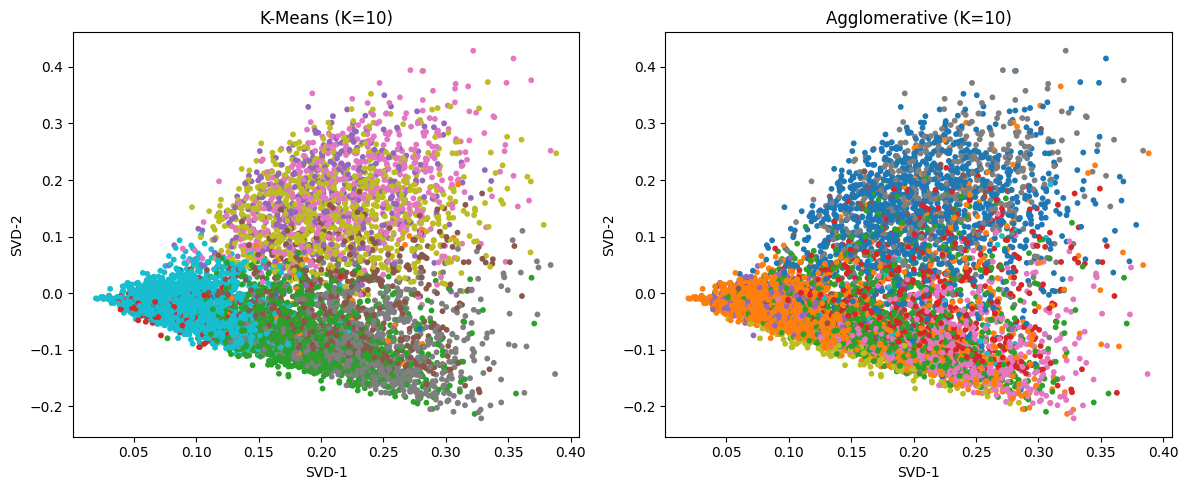

In [ ]:
from sklearn.decomposition import TruncatedSVD

# 5) Visualisation 2D
svd_2 = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd_2.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_km_best, s=10, cmap="tab10")
axes[0].set_title(f"K-Means (K={best_k})")
axes[0].set_xlabel("SVD-1")
axes[0].set_ylabel("SVD-2")

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_agg, s=10, cmap="tab10")
axes[1].set_title(f"Agglomerative (K={best_k})")
axes[1].set_xlabel("SVD-1")
axes[1].set_ylabel("SVD-2")

plt.tight_layout()
plt.show()